In [1]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt
from skfuzzy import control as ctrl

# Step 1: Define the Universe of Discourse

In [3]:
# Input
Distance = ctrl.Antecedent(np.arange(0, 101, 1), 'Distance')
Angle = ctrl.Antecedent(np.arange(-90, 91, 1), 'Angle')

# Output
Speed = ctrl.Consequent(np.arange(0, 101, 1), 'Speed')
Turn = ctrl.Consequent(np.arange(-90, 90, 1), 'Turn')

# Step 2: Define Membership Functions

In [5]:
# .universe refers to the range of values that the variable can take
Distance['Close'] = fuzz.trapmf(Distance.universe, [0, 0, 30, 50])
Distance['Medium'] = fuzz.trapmf(Distance.universe, [25, 40, 60, 75])
Distance['Far'] = fuzz.trapmf(Distance.universe, [50, 75, 100, 100])

Angle['Left'] = fuzz.trimf(Angle.universe, [-90, -90, -30])
Angle['Front'] = fuzz.trimf(Angle.universe, [-45, 0, 45])
Angle['Right'] = fuzz.trimf(Angle.universe, [30, 90, 90])

Speed['Slow'] = fuzz.trimf(Speed.universe, [0, 0, 40])
#Speed['Medium'] = fuzz.trimf(Speed.universe, [25, 50, 75])
Speed['Medium'] = fuzz.trapmf(Speed.universe, [30, 40, 60, 70])
Speed['Fast'] = fuzz.trimf(Speed.universe, [60, 100, 100])

Turn['Right'] = fuzz.trimf(Turn.universe, [-90, -90, 0])
Turn['Straight'] = fuzz.trimf(Turn.universe, [-15, 0, 15])
Turn['Left'] = fuzz.trimf(Turn.universe, [0, 90, 90])

# Turn['Right'] = fuzz.gaussmf(Turn.universe, -60, 30)   # غير الوسط ليكون -60 مثلاً
# Turn['Straight'] = fuzz.gaussmf(Turn.universe, 0, 20)
# Turn['Left'] = fuzz.gaussmf(Turn.universe, 60, 30)



# Step 3: Define the Rules

- القاعدة 1: إذا كانت المسافة قريبة والزاوية إلى اليسار، فإن السرعة تكون بطيئة والتوجيه إلى اليسار.
- القاعدة 2: إذا كانت المسافة قريبة والزاوية أمام، فإن السرعة تكون بطيئة والتوجيه مستقيم.
- القاعدة 3: إذا كانت المسافة قريبة والزاوية إلى اليمين، فإن السرعة تكون بطيئة والتوجيه إلى اليمين.

- القاعدة 4: إذا كانت المسافة متوسطة والزاوية إلى اليسار، فإن السرعة تكون متوسطة والتوجيه إلى اليسار.
- القاعدة 5: إذا كانت المسافة متوسطة والزاوية أمام، فإن السرعة تكون متوسطة والتوجيه مستقيم.
- القاعدة 6: إذا كانت المسافة متوسطة والزاوية إلى اليمين، فإن السرعة تكون متوسطة والتوجيه إلى اليمين.

- القاعدة 7: إذا كانت المسافة بعيدة والزاوية إلى اليسار، فإن السرعة تكون سريعة والتوجيه إلى اليسار.
- القاعدة 8: إذا كانت المسافة بعيدة والزاوية أمام، فإن السرعة تكون سريعة والتوجيه مستقيم.
- القاعدة 9: إذا كانت المسافة بعيدة والزاوية إلى اليمين، فإن السرعة تكون سريعة والتوجيه إلى اليمين.

In [8]:
#rule1 = ctrl.Rule(dirt_amount['low'] & cloth_amount['small'] & dirt_type['light'], washing_time['short'])

rule1 = ctrl.Rule(Distance['Close'] & Angle['Left'], (Speed['Slow'], Turn['Left']))
rule2 = ctrl.Rule(Distance['Close'] & Angle['Front'], (Speed['Slow'], Turn['Straight']))
rule3 = ctrl.Rule(Distance['Close'] & Angle['Right'], (Speed['Slow'], Turn['Right']))

rule4 = ctrl.Rule(Distance['Medium'] & Angle['Left'], (Speed['Medium'], Turn['Left']))
rule5 = ctrl.Rule(Distance['Medium'] & Angle['Front'], (Speed['Medium'], Turn['Straight']))
rule6 = ctrl.Rule(Distance['Medium'] & Angle['Right'], (Speed['Medium'], Turn['Right']))

rule7 = ctrl.Rule(Distance['Far'] & Angle['Left'], (Speed['Fast'], Turn['Left']))
rule8 = ctrl.Rule(Distance['Far'] & Angle['Front'], (Speed['Fast'], Turn['Straight']))
rule9 = ctrl.Rule(Distance['Far'] & Angle['Right'], (Speed['Fast'], Turn['Right']))

# Step 4: Create the Control System

In [10]:
#ControlSystem initializes the system with the defined rules.
#ControlSystemSimulation creates an instance for running simulations.
washing_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
washing_simulation = ctrl.ControlSystemSimulation(washing_ctrl)

speed_turn_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
speed_turn_sim = ctrl.ControlSystemSimulation(speed_turn_ctrl)

# Step 5: Input Example Values

In [12]:
speed_turn_sim.input['Distance'] = 40   # مثال: 40 سم
speed_turn_sim.input['Angle'] = -50  

# Step 6: Compute the Output

In [14]:
speed_turn_sim.compute()

In [15]:
#print(f"Recommended washing time (Mamdani): {washing_simulation.output['washing_time']:.2f} minutes")
print(f"Speed: {speed_turn_sim.output['Speed']:.2f}")
print(f"Turn: {speed_turn_sim.output['Turn']:.2f} degrees")

Speed: 34.24
Turn: 51.49 degrees


# Step 7: Visulization

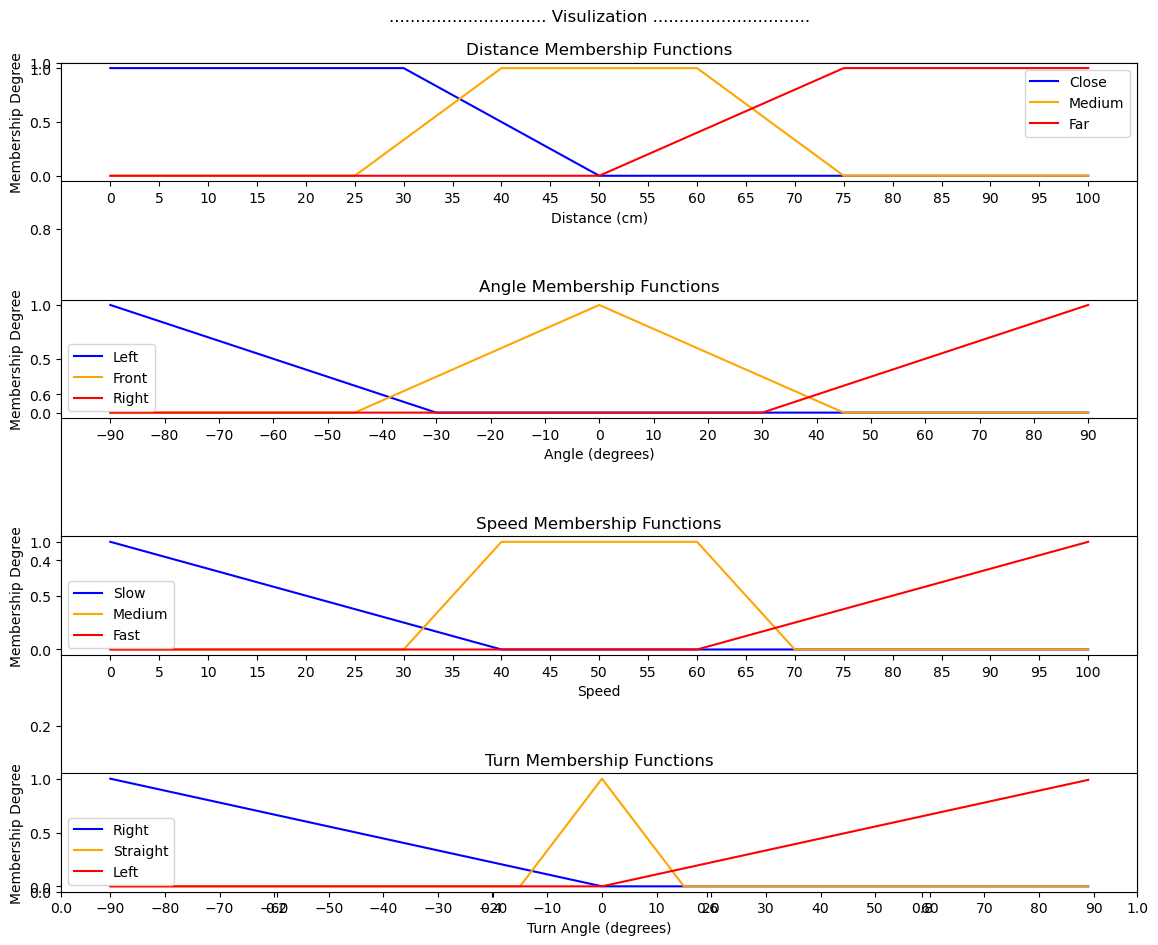

In [17]:
plt.figure(figsize=(12, 10))
plt.title(".............................. Visulization ..............................", pad=30)
# Distance
plt.subplot(4,1,1)
plt.plot(Distance.universe, Distance['Close'].mf, 'b', label='Close')
plt.plot(Distance.universe, Distance['Medium'].mf, color='orange', label='Medium')
plt.plot(Distance.universe, Distance['Far'].mf, 'r', label='Far')
plt.xticks(range(int(min(Distance.universe)), int(max(Distance.universe)) + 1, 5))
plt.title('Distance Membership Functions')
plt.xlabel('Distance (cm)')
plt.ylabel('Membership Degree')
plt.legend()

# Angle
plt.subplot(4,1,2)
plt.plot(Angle.universe, Angle['Left'].mf, 'b', label='Left')
plt.plot(Angle.universe, Angle['Front'].mf, color='orange', label='Front')
plt.plot(Angle.universe, Angle['Right'].mf, 'r', label='Right')
plt.xticks(range(-90, 91, 10))
plt.title('Angle Membership Functions')
plt.xlabel('Angle (degrees)')
plt.ylabel('Membership Degree')
plt.legend()

# Speed
plt.subplot(4,1,3)
plt.plot(Speed.universe, Speed['Slow'].mf, 'b', label='Slow')
plt.plot(Speed.universe, Speed['Medium'].mf, color='orange', label='Medium')
plt.plot(Speed.universe, Speed['Fast'].mf, 'r', label='Fast')
plt.xticks(range(int(min(Speed.universe)), int(max(Speed.universe)) + 1, 5))
plt.title('Speed Membership Functions')
plt.xlabel('Speed')
plt.ylabel('Membership Degree')
plt.legend()

# Turn
plt.subplot(4,1,4)
plt.plot(Turn.universe, Turn['Right'].mf, 'b', label='Right')
plt.plot(Turn.universe, Turn['Straight'].mf, color='orange', label='Straight')
plt.plot(Turn.universe, Turn['Left'].mf, 'r', label='Left')
plt.xticks(range(-90, 91, 10))
plt.title('Turn Membership Functions')
plt.xlabel('Turn Angle (degrees)')
plt.ylabel('Membership Degree')
plt.legend()

plt.tight_layout()
plt.subplots_adjust(hspace=1)
plt.show()